In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [3]:
data = pd.read_csv('../../TP2/data/univariate_linear_regression_dataset.csv',header=None)


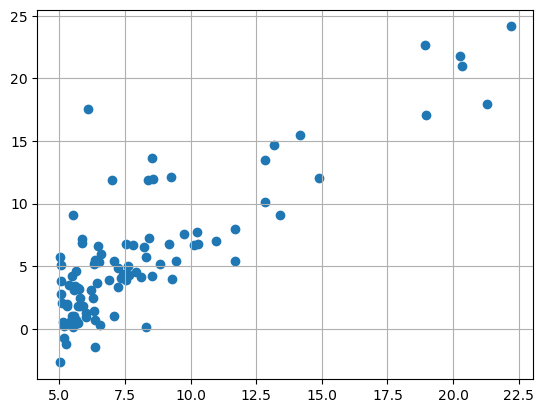

In [4]:
X = data.iloc[:,0]
Y = data.iloc[:,1]
axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
plt.show()

In [5]:
sl = stats.linregress(X,Y)
slope = sl.slope
intercept = sl.intercept
coef_corr = sl.rvalue

In [6]:
def predict(x):
    return slope*x + intercept

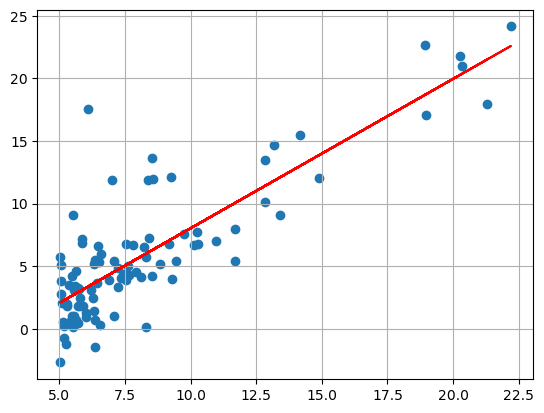

In [7]:
axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
fitLine = predict(X)
plt.plot(X, fitLine, color='red')
plt.show()

Regression Linéaire + Gradient Descent

In [8]:
def f(x, theta):
    return X.dot(theta)
def erreur_somme_des_distances(X,Y, theta):
    m = len(Y)
    return (1/(2*m))*np.sum((f(X,theta)-Y)**2)
def gradient(X,Y,theta):
    m = len(Y)
    return (1/m)*X.T.dot(f(X,theta)-Y)

In [9]:
def gradient_descent(X,Y,theta, learning_rate, n_iterations):
    historique_des_erreurs = np.zeros(n_iterations)
    for i in range(0, n_iterations):
        theta = theta - learning_rate * gradient(X,Y,theta)
        historique_des_erreurs[i] = erreur_somme_des_distances(X,Y,theta)
    return theta, historique_des_erreurs

let's apply gradient descent on the previous example

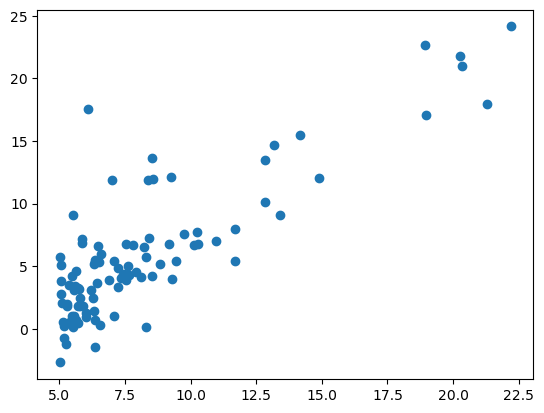

In [10]:
x = data.iloc[:,0]
n_samples = len(x)
y = data.iloc[:,1]
y = np.array(y).reshape(n_samples,1)
x = np.array(x).reshape(n_samples,1)
plt.scatter(x,y)
plt.show()

ajout de la colonne de biais a X

In [12]:
X = np.hstack((x, np.ones(x.shape)))

creation d'un vecteur parametre theta

In [13]:
theta = np.random.randn(2,1)
print(theta)

[[-0.37252125]
 [-2.57704971]]


In [15]:
n_iterations = 1000
learning_rate = 0.01
theta_final, historique_des_erreurs = gradient_descent(X, y, theta, learning_rate, n_iterations)
print(theta_final)

[[ 1.1688701]
 [-3.6552539]]


creation d'un vecteur de prediction

In [16]:
predictions = f(X, theta_final)

affiche les resultats de predictions (en rouge) par rapport a notre dataset

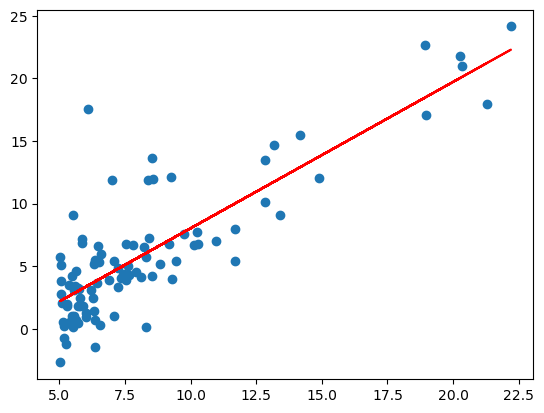

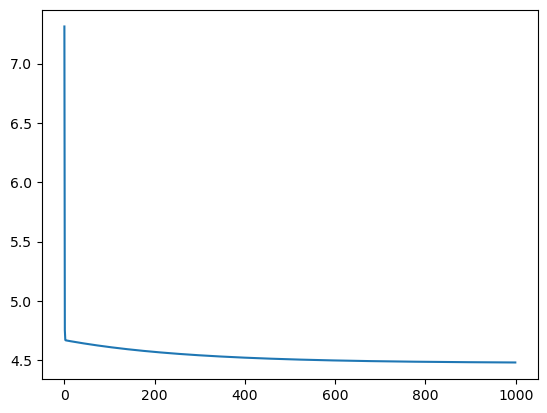

[[ 3.4866593 ]
 [ 2.80590935]
 [ 6.30188294]
 [ 4.53057719]
 [ 3.19409112]
 [ 6.14326726]
 [ 5.08368652]
 [ 6.37143071]
 [ 3.92627135]
 [ 2.25291691]
 [ 3.01981258]
 [12.9006222 ]
 [ 3.04704726]
 [ 6.17307345]
 [ 2.93799168]
 [ 2.63256592]
 [ 3.78507184]
 [ 2.3411666 ]
 [ 3.8601133 ]
 [ 4.60959281]
 [ 3.57900004]
 [20.03774303]
 [ 2.76195984]
 [ 3.73913524]
 [ 2.84939132]
 [18.48899015]
 [11.33901175]
 [ 9.15205579]
 [11.74577854]
 [22.29716893]
 [ 2.48411942]
 [ 4.04689874]
 [ 7.15469056]
 [ 3.23149496]
 [ 5.94245538]
 [ 5.61786015]
 [ 5.80780155]
 [ 2.89778254]
 [11.34836271]
 [ 3.7710454 ]
 [ 2.66470985]
 [ 4.38949457]
 [10.02987723]
 [ 3.0934514 ]
 [ 5.49080397]
 [ 4.63565861]
 [ 2.27115128]
 [ 3.1258291 ]
 [10.02052627]
 [ 2.82215665]
 [ 5.15826043]
 [ 2.54875793]
 [ 5.02232084]
 [ 5.23178236]
 [ 3.74696667]
 [ 3.77747418]
 [ 3.67847088]
 [ 2.93682281]
 [ 7.22716051]
 [ 7.39477648]
 [ 6.66049228]
 [ 2.39867501]
 [21.21713296]
 [13.77026155]
 [18.50535433]
 [ 4.78188426]
 [ 6.04064

In [17]:
plt.scatter(x, y)
plt.plot(x, predictions, color='red')
plt.show()
plt.figure()
plt.plot(range(n_iterations), historique_des_erreurs)
plt.show()
print(f(np.array([22.5,1]), theta_final))

Regression polynomiale: relation non lineaire entre des variables predictives et la variable cible

In [18]:
def afficher_pol(LPol):
    L = LPol[:]
    L.reverse()
    for i in range(len(L)):
        print('('+str(L[i])+'*X'+str(i)+')', end='+')

def evaluer_pol(LPol, x):
    s = 0
    L = LPol[:]
    L.reverse()
    for i in range(len(L)):
        s += L[i]*x**i
    return s


(-7.362071928641636*X0)+(13.349393505929857*X1)+(-7.014463905223911*X2)+(0.9601579473153521*X3)+(0.08192593570087735*X4)+(-0.00866475196882125*X5)+

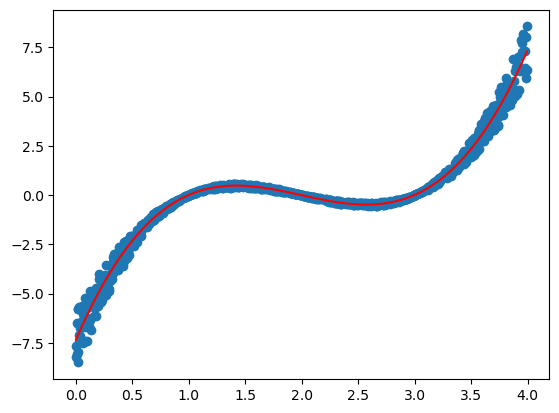

In [19]:
data = pd.read_csv("../../TP2/data/dataset_polynomial3.csv").to_numpy()
x = data[1:1001,0]
y = data[1:1001,1]
degre = 5
p = np.poly1d(np.polyfit(x, y, degre))
LPol = list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c="red")
plt.show()

(-7.3810986750057745*X0)+(13.533300726985443*X1)+(-7.384225069669098*X2)+(1.2313817968064154*X3)+

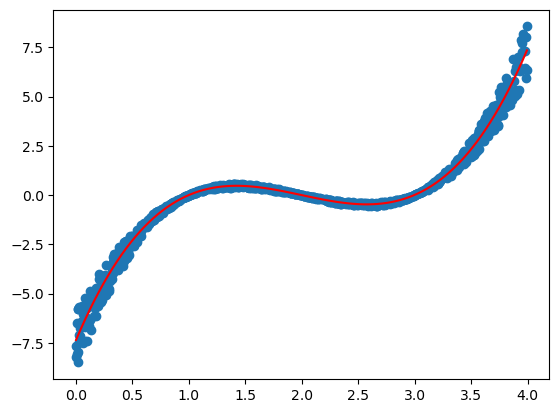

In [20]:
degre = 3
p = np.poly1d(np.polyfit(x, y, degre))
LPol = list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c="red")
plt.show()

(-7.240813166459944*X0)+(10.791595116250205*X1)+(6.732486462501594*X2)+(-32.93190211332829*X3)+(47.140160525777894*X4)+(-40.22726550691564*X5)+(21.917852969118037*X6)+(-7.621322467389607*X7)+(1.633239159940189*X8)+(-0.19619157974486157*X9)+(0.010092795814991186*X10)+

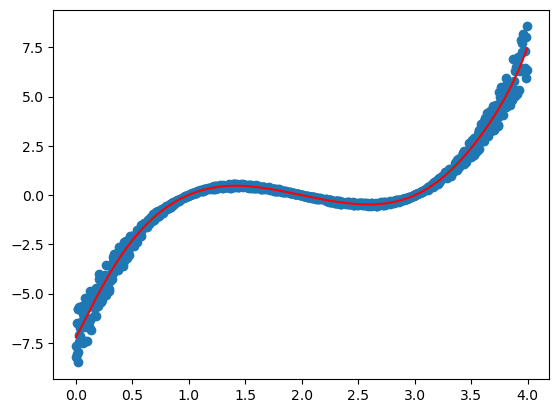

In [21]:
degre = 10
p = np.poly1d(np.polyfit(x, y, degre))
LPol = list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c="red")
plt.show()

(-3.4522811137986014*X0)+(1.8415298873090435*X1)+(-0.04095292850514463*X2)+

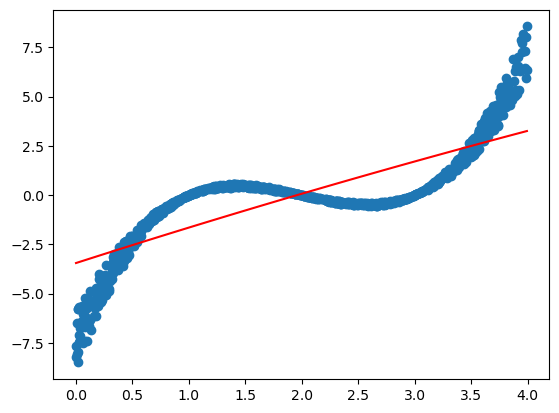

In [22]:
degre = 2
p = np.poly1d(np.polyfit(x, y, degre))
LPol = list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c="red")
plt.show()